# Lesson 9.2 - Advanced Computer Vision (detection/segmentation demo)

## Objectives

- Run pretrained detection and segmentation models from `torchvision`.
- Interpret outputs (boxes, labels, masks).
- Connect inference behavior to architecture choices.


In [1]:
from __future__ import annotations

import torch
from PIL import Image, ImageDraw
import torchvision
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt

print('torch', torch.__version__)
print('torchvision', torchvision.__version__)


torch 2.12.1+cu130
torchvision 0.27.1+cu130


## Load Sample Image

To keep this notebook self-contained, we generate a simple synthetic image with geometric objects.


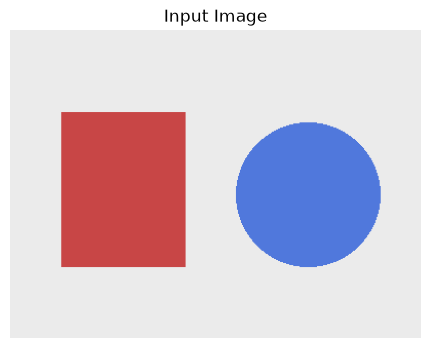

In [2]:
img = Image.new("RGB", (400, 300), color=(235, 235, 235))
draw = ImageDraw.Draw(img)
draw.rectangle((50, 80, 170, 230), fill=(200, 70, 70))
draw.ellipse((220, 90, 360, 230), fill=(80, 120, 220))

plt.figure(figsize=(6, 4))
plt.imshow(img)
plt.axis('off')
plt.title('Input Image')
plt.show()


## Object Detection with Faster R-CNN

Using pretrained COCO weights from `torchvision`.


In [3]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

weights_det = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model_det = fasterrcnn_resnet50_fpn(weights=weights_det)
model_det.eval()

x = F.to_tensor(img)
with torch.no_grad():
    pred = model_det([x])[0]

print('keys:', pred.keys())
print('num detections:', len(pred['boxes']))


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /home/ahmad/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


  0%|          | 0.00/160M [00:00<?, ?B/s]

  0%|          | 256k/160M [00:00<01:18, 2.12MB/s]

  1%|          | 1.38M/160M [00:00<00:23, 6.98MB/s]

  2%|▏         | 3.25M/160M [00:00<00:13, 12.2MB/s]

...

 96%|█████████▌| 153M/160M [00:07<00:00, 14.7MB/s]

 98%|█████████▊| 156M/160M [00:07<00:00, 18.9MB/s]

 99%|█████████▉| 158M/160M [00:07<00:00, 19.6MB/s]

100%|██████████| 160M/160M [00:07<00:00, 21.1MB/s]

keys: dict_keys(['boxes', 'labels', 'scores'])
num detections: 5


In [4]:
score_thr = 0.4
labels_map = weights_det.meta["categories"]

for i in range(min(5, len(pred['boxes']))):
    score = float(pred['scores'][i])
    if score < score_thr:
        continue
    label_id = int(pred['labels'][i])
    label_name = labels_map[label_id] if label_id < len(labels_map) else str(label_id)
    box = pred['boxes'][i].tolist()
    print(f"det {i}: label={label_name}, score={score:.3f}, box={[round(v,1) for v in box]}")


det 0: label=kite, score=0.642, box=[222.2, 93.8, 364.2, 225.1]


## Semantic Segmentation with FCN-ResNet50


In [5]:
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights

weights_seg = FCN_ResNet50_Weights.DEFAULT
model_seg = fcn_resnet50(weights=weights_seg)
model_seg.eval()

x_seg = weights_seg.transforms()(img).unsqueeze(0)
with torch.no_grad():
    out = model_seg(x_seg)["out"]

mask = out.argmax(1).squeeze().cpu().numpy()
print('mask shape:', mask.shape, 'unique classes:', len(set(mask.flatten().tolist())))


Downloading: "https://download.pytorch.org/models/fcn_resnet50_coco-1167a1af.pth" to /home/ahmad/.cache/torch/hub/checkpoints/fcn_resnet50_coco-1167a1af.pth


  0%|          | 0.00/135M [00:00<?, ?B/s]

  0%|          | 256k/135M [00:00<01:11, 1.97MB/s]

  1%|          | 896k/135M [00:00<00:33, 4.21MB/s]

  2%|▏         | 2.50M/135M [00:00<00:14, 9.42MB/s]

...

 95%|█████████▍| 128M/135M [00:05<00:00, 31.1MB/s]

 97%|█████████▋| 131M/135M [00:05<00:00, 30.2MB/s]

 99%|█████████▉| 134M/135M [00:05<00:00, 27.1MB/s]

100%|██████████| 135M/135M [00:05<00:00, 25.4MB/s]

mask shape: (520, 693) unique classes: 1


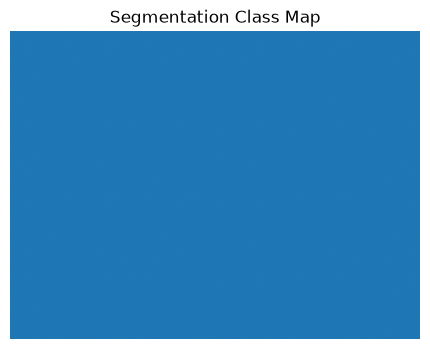

In [6]:
plt.figure(figsize=(6, 4))
plt.imshow(mask, cmap='tab20')
plt.axis('off')
plt.title('Segmentation Class Map')
plt.show()


## Connect to Theory

- Faster R-CNN (two-stage) emphasizes precise localization.
- Segmentation model produces dense per-pixel predictions.
- Task objective determines architecture and runtime characteristics.


## Business Case Studies & Exceptions

### Case A: Manufacturing Defect Inspection

Detection/segmentation models can localize defects for automated QA. Production success depends on camera consistency, labeling quality, and threshold tuning.

### Case B: Retail Shelf Analytics

Object detection tracks shelf availability and planogram compliance. Edge deployment may be required to reduce cloud costs and preserve latency.

### Exceptions

- For simple binary pass/fail checks, lightweight classifiers can outperform heavy detectors on cost and throughput.
- In privacy-sensitive environments, non-visual sensing may be preferable.


## Interview Questions & Answers

1. **Q: Detection vs segmentation?**
   **A:** Detection predicts boxes/classes; segmentation predicts pixel labels.
2. **Q: When prefer two-stage detectors?**
   **A:** When localization quality matters more than speed.
3. **Q: What is semantic segmentation output?**
   **A:** A class label for each pixel.
4. **Q: What does `scores` represent in detection output?**
   **A:** Confidence for each predicted box/class.
5. **Q: How do you improve edge inference speed?**
   **A:** Quantization, pruning, and optimized runtimes.
6. **Q: Why do pretrained weights help?**
   **A:** They transfer useful visual features to low-data tasks.
7. **Q: How do you evaluate detection quality?**
   **A:** mAP with IoU thresholds and per-class PR curves.
8. **Q: What is a common CV deployment risk?**
   **A:** Domain shift from training to production imagery.
9. **Q: How do you reduce false positives?**
   **A:** Threshold tuning, hard-negative mining, better calibration.
10. **Q: Why monitor confidence distribution over time?**
   **A:** It helps detect drift and model degradation.
